# 01 — Repository Setup: проверка инфраструктуры

Этот ноутбук демонстрирует, что вся инфраструктура репозитория работает end-to-end:

1. загрузка данных через единый интерфейс (`src.data.load_data`);
2. построение графика цены;
3. расчет индикатора (`src.indicators`);
4. запуск тестового бэктеста одной функцией (`src.backtesting.run_backtest`);
5. вывод статистики и стандартного отчета (`src.analytics`);
6. штатные графики vectorbt.

> Все графики выводятся статичными PNG (plotly + kaleido), поэтому корректно отображаются на GitHub.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import vectorbt as vbt

from src.data import available_sources, load_data
from src.indicators import rsi, sma
from src.strategies import available_strategies, get_strategy
from src.backtesting import BacktestConfig, run_backtest
from src.analytics import PerformanceReport
from src.visualization import equity_drawdown_chart, price_chart, setup_github_rendering, show

# Статичный PNG-рендеринг: обязательный вызов для GitHub-совместимых графиков.
setup_github_rendering()

print("vectorbt:", vbt.__version__)
print("Источники данных:", available_sources())
print("Стратегии:", available_strategies())

vectorbt: 1.0.0
Источники данных: ['csv', 'parquet', 'yahoo']
Стратегии: ['ma_crossover', 'rsi_reversion']


## 1. Загрузка данных

Единая точка входа — `load_data(source, symbols, ...)`. Источник задается строкой
(`"yahoo"`, `"csv"`, `"parquet"`, позже — `"moex"`, `"polygon"`), интерфейс не меняется.

Сначала пробуем Yahoo Finance; если сеть недоступна (например, в CI-песочнице),
прозрачно переключаемся на локальный CSV — **через тот же интерфейс**.

In [2]:
SYMBOL = "AAPL"
try:
    data = load_data("yahoo", SYMBOL, start="2018-01-01", end="2025-06-30")
    print("Данные получены из Yahoo Finance")
except Exception as exc:
    print(f"Yahoo Finance недоступен ({type(exc).__name__}), переключаемся на локальный CSV")
    SYMBOL = "SAMPLE"
    data = load_data("csv", SYMBOL)

data

2026-07-03 19:45:58,732 | INFO    | src.data.yahoo_loader | Downloading AAPL from Yahoo Finance (1d, 2018-01-01..2025-06-30)


Failed to get ticker 'AAPL' reason: Failed to perform, curl: (56) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.



1 Failed download:


['AAPL']: ProxyError('Failed to perform, curl: (56) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


Yahoo Finance недоступен (ValueError), переключаемся на локальный CSV


MarketData(source='csv', timeframe='1d', {'SAMPLE': '2018-01-01..2025-08-29 (2000)'})

In [3]:
ohlcv = data.get(SYMBOL)
ohlcv.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2025-08-25,223.231798,224.465206,220.932838,222.160326,344263.0
2025-08-26,221.697975,225.418612,220.638522,224.346502,845804.0
2025-08-27,224.417707,228.744671,219.561830,223.878396,431373.0
2025-08-28,224.390956,227.190031,219.784041,222.560280,457760.0
2025-08-29,222.624378,223.520350,219.106035,219.991410,693771.0


## 2. График цены

Свечной график с объемом и парой скользящих средних, собранный хелпером
`src.visualization.price_chart`.

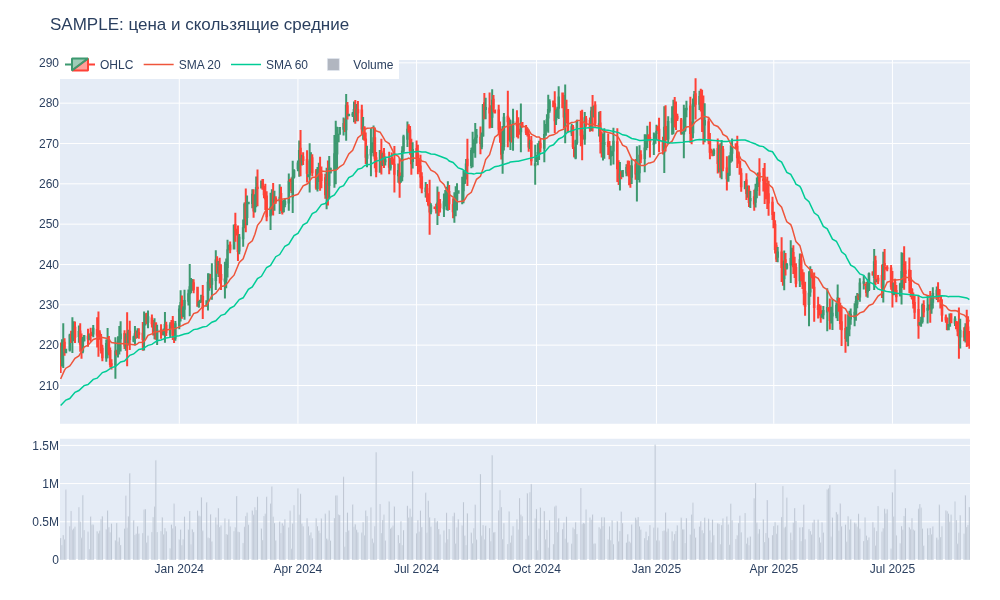

In [4]:
close = ohlcv["Close"]
overlays = {"SMA 20": sma(close, 20), "SMA 60": sma(close, 60)}

fig = price_chart(ohlcv.iloc[-500:], title=f"{SYMBOL}: цена и скользящие средние",
                  overlays={k: v.iloc[-500:] for k, v in overlays.items()})
show(fig)

## 3. Индикатор: RSI

Индикаторы живут в `src.indicators` — тонкие обертки над vectorbt,
чтобы стратегии не зависели от конкретной реализации.

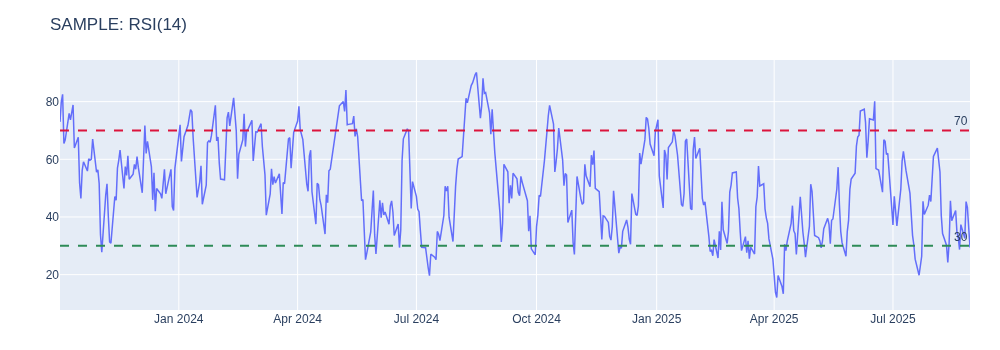

count    1986.00
mean       52.39
std        16.66
min        10.49
25%        40.47
50%        52.68
75%        65.19
max        91.85
Name: (14, True, Close), dtype: float64

In [5]:
rsi_series = rsi(close, window=14)

import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=rsi_series.index[-500:], y=rsi_series.iloc[-500:], name="RSI(14)", line=dict(width=1.5)))
fig.add_hline(y=70, line_dash="dash", line_color="crimson", annotation_text="70")
fig.add_hline(y=30, line_dash="dash", line_color="seagreen", annotation_text="30")
fig.update_layout(title=f"{SYMBOL}: RSI(14)", width=1000, height=350, margin=dict(l=60, r=30, t=60, b=40))
show(fig)

rsi_series.dropna().describe().round(2)

## 4. Тестовый бэктест одной функцией

Любая зарегистрированная стратегия запускается вызовом `run_backtest(...)`.
Стратегия возвращает стандартизованные сигналы: `entries`, `exits`,
`short_entries`, `short_exits`, параметры и описание.

In [6]:
strategy = get_strategy("ma_crossover", fast_window=20, slow_window=60)
signals = strategy.signals(data, SYMBOL)

print("Стратегия:", strategy)
print("Описание:", signals.description)
print("Параметры:", signals.params)
signals.stats()

Стратегия: MACrossoverStrategy(fast_window=20, slow_window=60, ewm=False, allow_short=False)
Описание: Trend-following: fast/slow moving average crossover. Long on golden cross, flat (or short) on death cross.
Параметры: {'fast_window': 20, 'slow_window': 60, 'ewm': False, 'allow_short': False}


entries          16
exits            17
short_entries     0
short_exits       0
Name: signal_count, dtype: int64

In [7]:
config = BacktestConfig(init_cash=100_000, fees=0.001, slippage=0.0005, freq="1D")

result = run_backtest("ma_crossover", data, params={"fast_window": 20, "slow_window": 60},
                      config=config, symbol=SYMBOL)
result

2026-07-03 19:46:03,775 | INFO    | src.backtesting.engine | Backtesting ma_crossover on SAMPLE: 2000 bars, {'entries': 16, 'exits': 17, 'short_entries': 0, 'short_exits': 0}


BacktestResult(strategy='ma_crossover', symbol='SAMPLE', total_return=97.22%)

## 5. Статистика

Полная таблица метрик vectorbt плюс компактный стандартизованный набор
из `src.analytics.key_metrics`.

In [8]:
result.stats()

Start                                 2018-01-01 00:00:00
End                                   2025-08-29 00:00:00
Period                                 2000 days 00:00:00
Start Value                                      100000.0
End Value                                   197224.699612
Total Return [%]                                  97.2247
Benchmark Return [%]                            121.87145
Max Gross Exposure [%]                              100.0
Total Fees Paid                                4863.74472
Max Drawdown [%]                                28.106066
Max Drawdown Duration                   348 days 00:00:00
Total Trades                                           16
Total Closed Trades                                    16
Total Open Trades                                       0
Open Trade PnL                                        0.0
Win Rate [%]                                        43.75
Best Trade [%]                                  37.327735
Worst Trade [%

In [9]:
report = PerformanceReport.from_result(result)
report.summary().round(3)

total_return_pct                 97.225
benchmark_return_pct            121.871
max_drawdown_pct                 28.106
sharpe_ratio                      0.813
sortino_ratio                     1.213
calmar_ratio                      0.470
win_rate_pct                     43.750
profit_factor                     2.600
total_trades                     16.000
expectancy                     6076.544
annualized_return_pct            13.196
annualized_volatility_pct        17.041
final_value                  197224.700
Name: ma_crossover:SAMPLE, dtype: float64

## 6. Анализ результатов: equity, drawdown, сделки

Стандартный шаблон анализа: кривая капитала, профиль просадки и список сделок.

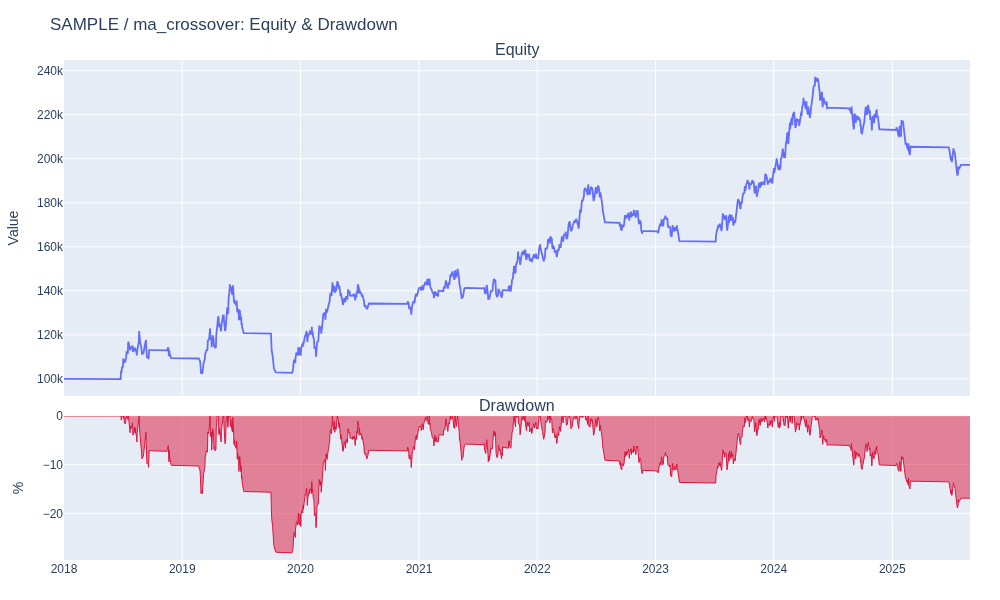

In [10]:
show(equity_drawdown_chart(result.equity(), result.drawdown(),
                           title=f"{SYMBOL} / ma_crossover: Equity & Drawdown"))

In [11]:
trades = result.trades()
print(f"Всего сделок: {len(trades)}")
trades.tail(10)

Всего сделок: 16


,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id
6,6,0,927.353141,2020-11-26,144.616493,134.110559,2021-03-02,151.188933,140.205532,5820.657344,0.043402,Long,Closed,6
7,7,0,888.294808,2021-03-17,157.521355,139.925401,2021-05-24,159.300721,141.506003,1299.170454,0.009285,Long,Closed,7
8,8,0,877.758340,2021-07-20,160.890837,141.223274,2021-09-17,160.016721,140.456011,-1048.942029,-0.007428,Long,Closed,8
9,9,0,860.703462,2021-10-04,162.861411,140.175380,2022-07-28,199.039907,171.314337,30827.467143,0.219921,Long,Closed,9
10,10,0,814.540237,2022-09-12,209.900067,170.972050,2022-11-22,205.565020,167.440980,-3869.483446,-0.022632,Long,Closed,10
11,11,0,756.811226,2023-01-06,220.803322,167.106432,2023-03-14,215.052370,162.754048,-4682.245227,-0.028020,Long,Closed,11
12,12,0,849.349397,2023-07-06,191.239159,162.428865,2024-06-17,263.078724,223.445755,60631.015991,0.373277,Long,Closed,12
13,13,0,797.549131,2024-08-21,279.605734,222.999310,2024-11-20,267.832661,213.609706,-9826.213366,-0.044064,Long,Closed,13
14,14,0,771.624357,2025-01-13,276.278103,213.182913,2025-02-26,266.559079,205.683478,-7918.301694,-0.037143,Long,Closed,14
15,15,0,855.264706,2025-06-24,240.010515,205.272522,2025-07-31,230.831602,197.422122,-8253.094950,-0.040206,Long,Closed,15


## 7. Графики vectorbt

Штатные интерактивные графики vectorbt тоже выводим через `show(...)` —
хелпер конвертирует их в статичный PNG, который отображается на GitHub.

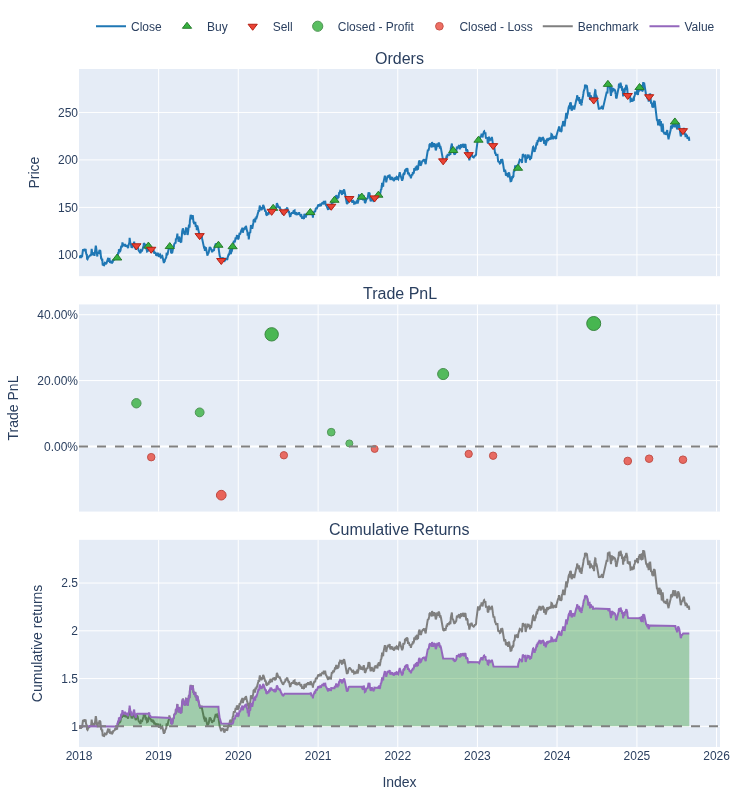

In [12]:
show(result.portfolio.plot(), height=800)

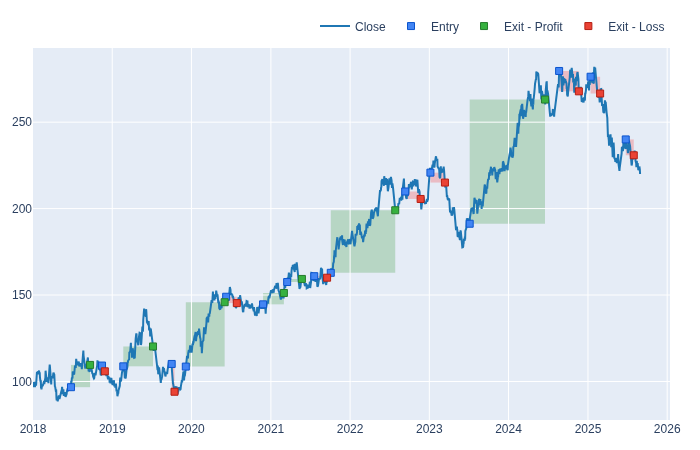

In [13]:
show(result.portfolio.trades.plot(), height=450)

## Итог

Инфраструктура работает end-to-end:

- **Данные**: единый интерфейс `load_data` (CSV / Parquet / Yahoo, расширяется реестром);
- **Стратегии**: единый контракт `StrategySignals` (entries / exits / short entries / short exits / params / description);
- **Бэктест**: одна функция `run_backtest` для любой стратегии;
- **Аналитика**: стандартный отчет (equity, drawdown, сделки, метрики);
- **Графики**: статичные PNG, корректно отображаются на GitHub.

Следующие шаги исследования (вне рамок этого этапа): подбор параметров через
`src.optimization.grid_search`, walk-forward валидация, добавление MOEX/Polygon-лоадеров.